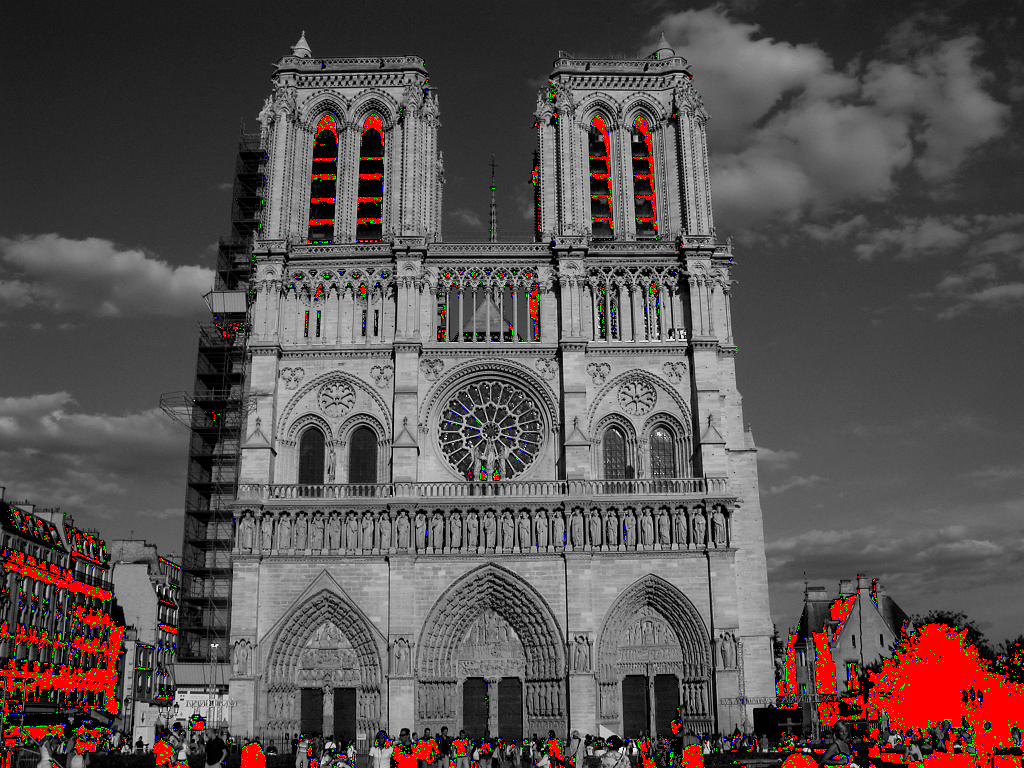

Wiener auto: estimated noise sigma = 0.09593
1.1 Wiener  — MSE: 1171.9824  SNR: 12.68 dB


[image row: 3 images]
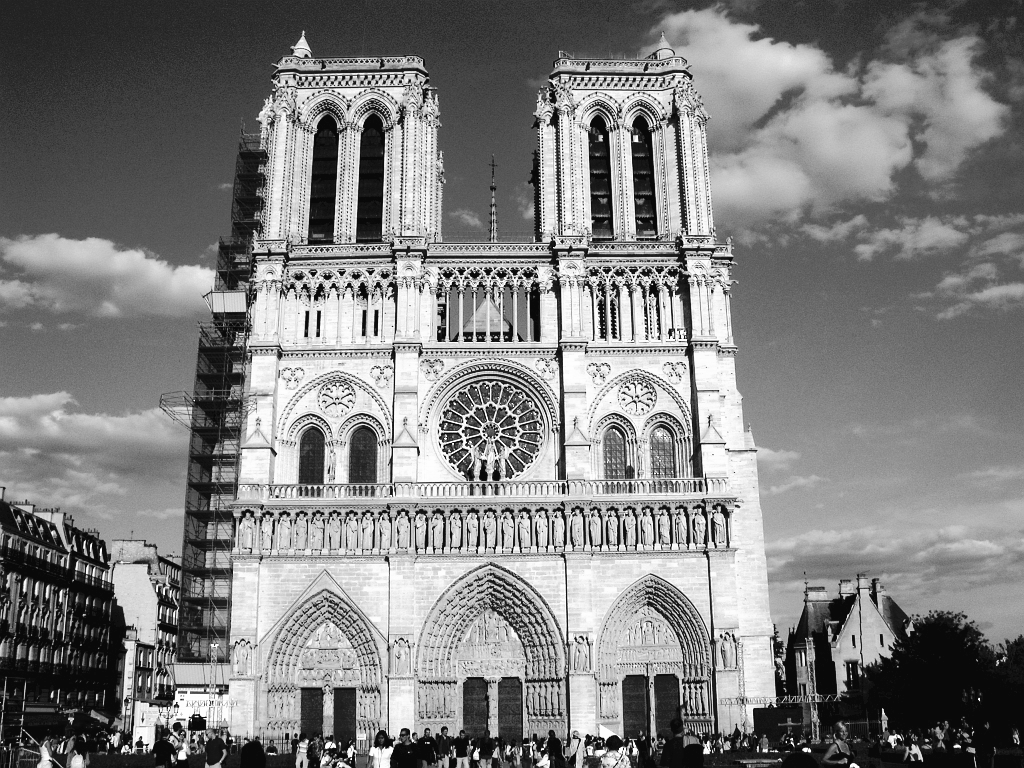
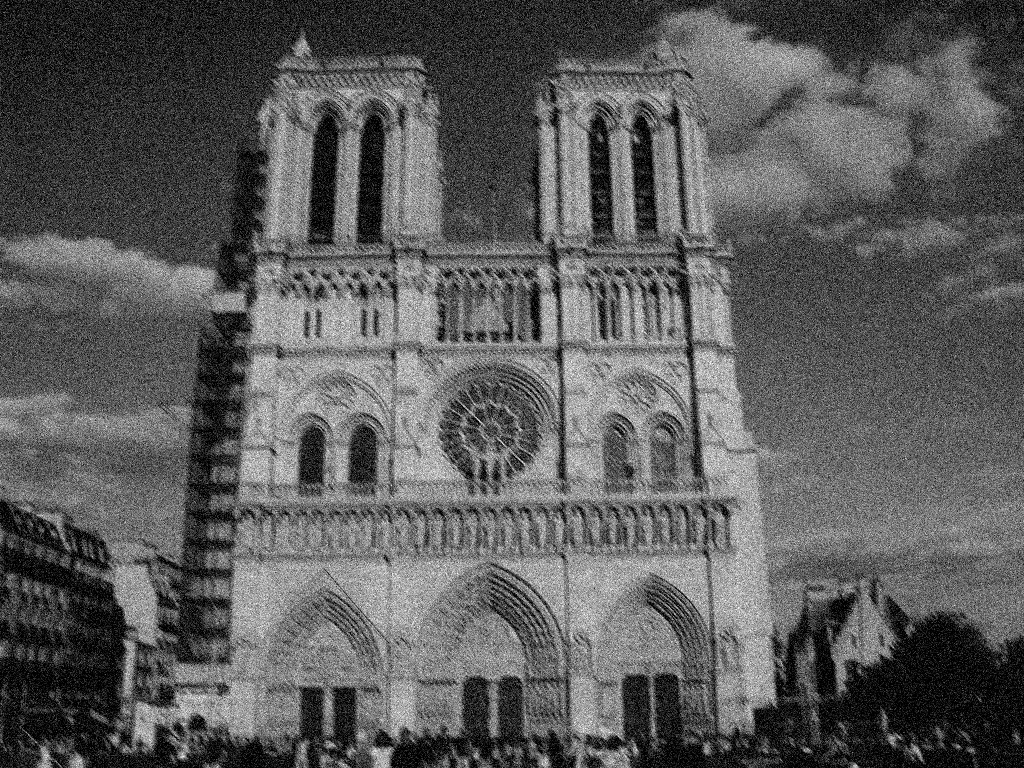
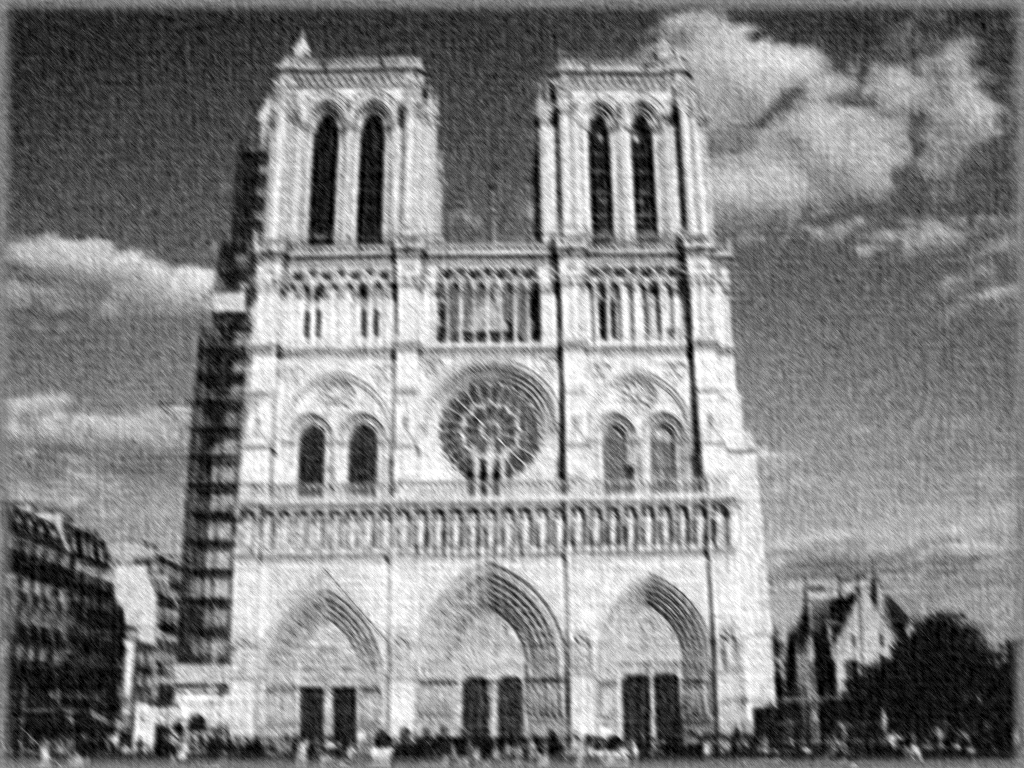

In [13]:
 #include "/home/ahrgm/Projects/imgPrcsngC/kernel/helpers.h"

    const char *src_images = "/home/ahrgm/Projects/imgPrcsngC/Course/images/";
    const char *save_path  = "/home/ahrgm/Projects/imgPrcsngC/Course/HW/HW3/";

    char path_buf[512];

    /* Ensure output directories exist */
    system("mkdir -p /home/ahrgm/Projects/imgPrcsngC/Course/HW/HW3/Problem1/1.1");
    system("mkdir -p /home/ahrgm/Projects/imgPrcsngC/Course/HW/HW3/Problem1/1.2");
    system("mkdir -p /home/ahrgm/Projects/imgPrcsngC/Course/HW/HW3/Problem2");

    /* =========================================================
     * Problem 1.1 — Known degradation and Wiener restoration
     * ========================================================= */
    {
        BMPImages        images;
        images.count = 3;

        images.images = (BMPImage**) malloc(sizeof(BMPImage*)*images.count);


        MotionBlurKernel *mbk;
        Filter           *wf;
        int               w, h;
 
        snprintf(path_buf, sizeof(path_buf), "%s%s", src_images, "building.bmp");
        images.images[0] = readBMP(path_buf);

        show_bmp(images.images[0], "Original Corrupted Image data");
        snprintf(path_buf, sizeof(path_buf), "%s%s", save_path, "Problem1/1.1/original_building.bmp");
        writeBMP(path_buf, images.images[0]);

        images.images[0] = apply_histogram_equalization(images.images[0], 0);


        if (images.images[0]) {
            w = images.images[0]->info_header.width_px;
            h = abs(images.images[0]->info_header.height_px);

            /* (a) Degrade: 7-pixel motion blur at 45 degrees + noise */
            mbk        = (MotionBlurKernel *)create_kernel(
                              31, 31, NULL, sizeof(MotionBlurKernel));
            mbk->L     = 7;
            mbk->theta = 45.0;
            motion_blur_init((Kernel *)mbk);

            images.images[1] = apply_kernel_to_bmp(images.images[0], (Kernel *)mbk);
            add_gaussian_noise(images.images[1], 0.01);

            snprintf(path_buf, sizeof(path_buf), "%s%s", save_path, "Problem1/1.1/degraded.bmp");
            writeBMP(path_buf, images.images[1]);

            /*
             * (b) Restore with adaptive Wiener filter.
             *
             * create_wiener_filter_auto:
             *   - estimates noise sigma from the wavelet HH1 subband of
             *     `blurred` (no manual K needed)
             *   - builds a per-frequency K_spectrum via the Wiener-Hunt
             *     formula so regularisation is strongest at blur nulls
             *   - sets apod_margin to suppress border ringing
             */
            wf       = create_wiener_filter_auto(FILTER_DOMAIN_DFT, w, h,
                                                 (Kernel *)mbk, images.images[1]);
            images.images[2] = apply_frequency_filter_to_bmp(images.images[1], wf);

            snprintf(path_buf, sizeof(path_buf), "%s%s", save_path, "Problem1/1.1/restored_wiener.bmp");
            writeBMP(path_buf, images.images[2]);

            {
                double mse_w = calculate_mse(images.images[0], images.images[2]);
                double snr_w = calculate_snr(images.images[0], images.images[2]);
                printf("1.1 Wiener  — MSE: %.4f  SNR: %.2f dB\n", mse_w, snr_w);
            }
            
            static const char *names[] = {"Equalized", "Blurred", "Restored Image" };
            show_bmp_row(images, names , images.count);


            destroy_wiener_filter(wf);
            destroy_kernel((Kernel *)mbk);
            freeBMPImages(images);
        }
    }

originally the 8-bit grayscale image was displaying red pixels in areas of max darkness. In the past ive seen this happen to 24 bit grayscale image files that were corrupted but this file seems to read into the program just fine. The problem does go away after equalization(shown). This may be a problem appears to be rooted in the jupyter notebook, because the image does not exhibit these pixel artifacts when written to a new file.

Pre-computed noise sigma = 0.00291
1.2 Best Result: L=5  Theta=90.0  MSE=460.4034


[image row: 3 images]
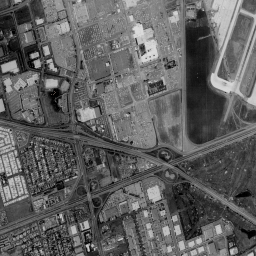
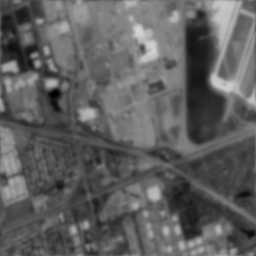
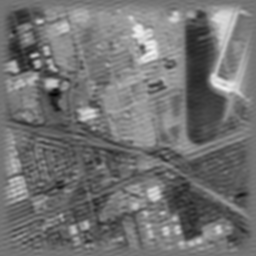

In [14]:
#include "/home/ahrgm/Projects/imgPrcsngC/kernel/helpers.h"

const char *src_images = "/home/ahrgm/Projects/imgPrcsngC/Course/images/";
const char *save_path  = "/home/ahrgm/Projects/imgPrcsngC/Course/HW/HW3/";
char path_buf[512];

BMPImages        images;
images.count = 3;

images.images = (BMPImage**) malloc(sizeof(BMPImage*)*images.count);

BMPImage         *res;
MotionBlurKernel *mbk;
Kernel           *base_k;
Filter           *f;
int               w, h, li, ai, y, x;
double            mse, min_mse;
int               best_L;
double            best_theta;
double            sigma_n;
double           *shared_K;
fftw_complex     *precomp_G;

static const int    blur_lengths[] = {1, 3, 5, 7, 9};
static const double blur_angles[]  = {0.0, 45.0, 90.0, 135.0, 180.0};

snprintf(path_buf, sizeof(path_buf), "%s%s", src_images, "urban0.bmp");
images.images[0] = readBMP(path_buf);

snprintf(path_buf, sizeof(path_buf), "%s%s", src_images, "urbanblur.bmp");
images.images[1] = readBMP(path_buf);


    if (!images.images[0] || !images.images[1]) {
            fprintf(stderr, "Error: could not load urbanblur.bmp or urban0.bmp\n");
            if (images.images[1]) freeBMPImages(images);
            if (images.images[0]) freeBMPImages(images);
            
        }

w = images.images[1]->info_header.width_px;
h = abs(images.images[1]->info_header.height_px);

mbk    = (MotionBlurKernel *)create_kernel(31, 31, NULL, sizeof(MotionBlurKernel));
base_k = (Kernel *)mbk;

min_mse    = 1e9;
best_L     = 0;
best_theta = 0.0;

        /*
         * Pre-compute the three quantities that are identical for every
         * candidate in the search grid — they depend only on img_blur,
         * not on the kernel parameters (L, theta):
         *
         *   1. sigma_n     — noise std-dev from the Haar HH1 subband
         *   2. shared_K    — per-frequency NSR array (Wiener-Hunt formula)
         *   3. precomp_G   — forward DFT of the apodised blurred image
         *
         * Without this, create_wiener_filter_auto recomputes all three
         * from scratch on every one of the 25 iterations.
         */

{
  Filter       *f_tmp;
  WienerFilter *wf_tmp;

  /* Use a dummy L=1 kernel just to set apod_margin consistently */
mbk->L = 1; mbk->theta = 0.0;
motion_blur_init(base_k);
f_tmp  = create_wiener_filter(FILTER_DOMAIN_DFT, w, h, base_k, 0.0);
            /* apod_margin for a 31x31 kernel = 31/2 + 1 = 16 */
f_tmp->apod_margin = 16;

sigma_n = estimate_noise_sigma(images.images[1]);
printf("Pre-computed noise sigma = %.5f\n", sigma_n);

wiener_build_K_spectrum((WienerFilter *)f_tmp, images.images[1], sigma_n);

            /* Steal K_spectrum from tmp filter into shared_K */
wf_tmp = (WienerFilter *)f_tmp;
shared_K = wf_tmp->K_spectrum;
wf_tmp->K_spectrum = NULL;   /* prevent free inside destroy */

            /* Pre-compute G = FFT(apodised img_blur) */
precomp_G = fftw_alloc_complex(w * h);
filter_preload_input_dft(f_tmp, images.images[1] , precomp_G);

destroy_wiener_filter(f_tmp);

}



for (li = 0; li < 5; li++) {
    for (ai = 0; ai < 5; ai++) {
                /* Reset kernel mask */
        for (y = 0; y < base_k->height; y++){
            for (x = 0; x < base_k->width; x++){
                
            base_k->mask[y][x] = 0.0f;
            mbk->L     = blur_lengths[li];
            mbk->theta = blur_angles[ai];
            motion_blur_init(base_k);
    }}
                /*
                 * Build only the kernel-specific part (OTF of the blur PSF).
                 * K_spectrum and apod_margin come from the pre-computed values.
                 */
            f = create_wiener_filter(FILTER_DOMAIN_DFT, w, h, base_k, 0.0);
                {
                    WienerFilter *wf = (WienerFilter *)f;

                    /* Attach shared K_spectrum (not owned — don't free it) */
                    if (wf->K_spectrum) free(wf->K_spectrum);
                    wf->K_spectrum = shared_K;

                    f->apod_margin  = 16;

                    /* Point to the pre-computed G so filter_execute skips
                     * the redundant forward FFT of img_blur */
                    f->preloaded_G = precomp_G;
                }

                res = apply_frequency_filter_to_bmp(images.images[1], f);

                /* Detach shared pointers before destroy to avoid double-free */
                ((WienerFilter *)f)->K_spectrum = NULL;
                f->preloaded_G = NULL;

                if (res) {
                    mse = calculate_mse(images.images[0], res);
                    if (mse < min_mse) {
                        min_mse    = mse;
                        best_L     = blur_lengths[li];
                        best_theta = blur_angles[ai];
                        if (images.images[2]) freeBMPImage(images.images[2]);
                        images.images[2] = res;
                    } else {
                        freeBMPImage(res);
                    }
                }
                destroy_wiener_filter(f);
            }
        }

        fftw_free(precomp_G);
        free(shared_K);

        printf("1.2 Best Result: L=%d  Theta=%.1f  MSE=%.4f\n",
               best_L, best_theta, min_mse);

static const char *names[] = {"Original", "Blurred", "Restored Image" };

        if (images.images[2]) {
            snprintf(path_buf, sizeof(path_buf), "%s%s",save_path, "Problem1/1.2/best_restoration.bmp");
            writeBMP(path_buf, images.images[2]);
            show_bmp_row(images, names , images.count);
            freeBMPImages(images);
        }

        destroy_kernel(base_k);

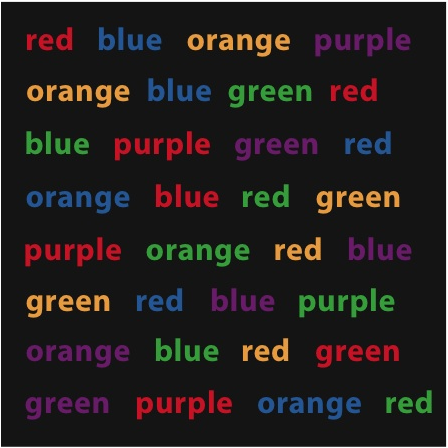

[image row: 5 images]
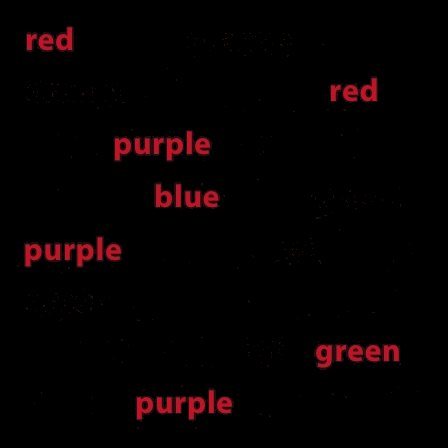
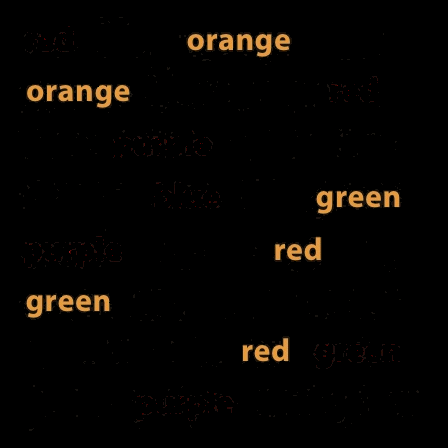
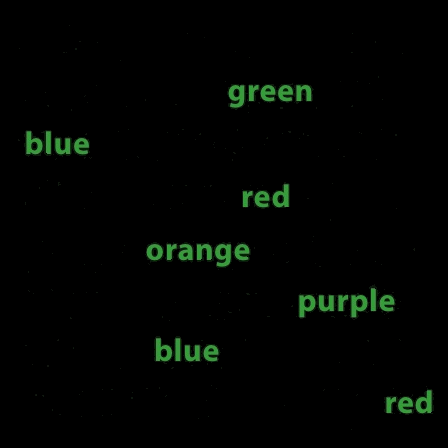
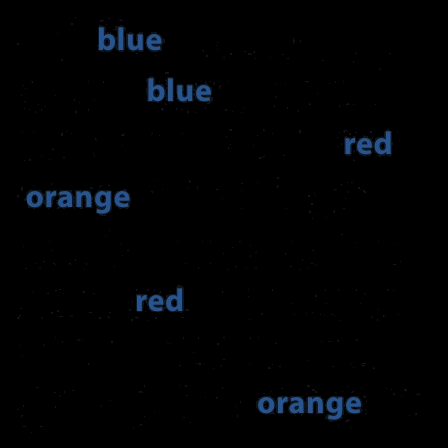
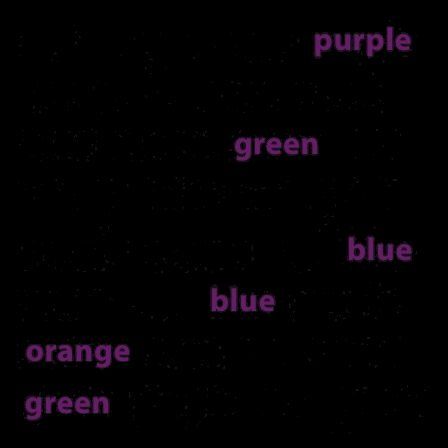

In [15]:
#include "/home/ahrgm/Projects/imgPrcsngC/kernel/helpers.h"


const char *src_images = "/home/ahrgm/Projects/imgPrcsngC/Course/images/";
const char *save_path  = "/home/ahrgm/Projects/imgPrcsngC/Course/HW/HW3/";
char path_buf[512];
    
    /* =========================================================
     * Problem 2 — HSI colour segmentation
     * ========================================================= */
    {
        BMPImage  *color_img;
        BMPImages  results;
        int        i;

        static const char *names[]       = {"red", "orange", "green",
                                            "blue", "purple"};
        static const float target_hues[] = {0.0f, 20.0f, 120.0f,
                                            220.0f, 300.0f};
        static const int   n_hues        = 5;
        const float        hue_tol       = 20.0f;   /* widened for orange/red proximity */
        const float        min_sat       = 0.15f;

        snprintf(path_buf, sizeof(path_buf), "%s%s", src_images, "color_image.bmp");
        color_img = readBMP(path_buf);

        if (color_img) {
            results = segment_color_hsi(color_img, target_hues, n_hues,
                                        hue_tol, min_sat);

            for (i = 0; i < results.count; i++) {
                char rel[64];
                snprintf(rel, sizeof(rel), "/Problem2/%s.bmp", names[i]);
                snprintf(path_buf, sizeof(path_buf), "%s%s", save_path, rel);
                writeBMP(path_buf, results.images[i]);
            }

            show_bmp(color_img, "original");
            show_bmp_row(results, names, results.count);
            
            freeBMPImages(results);
            freeBMPImage(color_img);
        }
    }